# SigLIP2 training and product retrieval playground

This notebook continues from `siglip2_product_exploration.ipynb`. It fine-tunes the shared image-text embedding space on real Home & Kitchen pairs, generates reusable image and description embeddings, and demonstrates three searches:

1. product image → 10 visually similar product images;
2. free text → 10 matching product images (cross-modal search);
3. free text → 10 matching product descriptions (semantic text search).

The defaults are a bounded MPS-friendly playground run, not a production training recipe. They train 7.68M pooling/similarity parameters on 64 pairs and build a 250-product held-out search catalog.

## 0. Environment and experiment controls

Select the **RecSystem — SigLIP2 (Python 3.11)** kernel. Increase `TRAIN_ROWS` or `CATALOG_ROWS` only after this default run completes. Set `CATALOG_ROWS=None` to embed the full 1,000-product test split. Full-backbone training is intentionally blocked unless a CUDA device is active.

In [1]:
from contextlib import nullcontext
from pathlib import Path
import json
import platform
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoProcessor

SEED = 42
MODEL_ID = "google/siglip2-base-patch16-224"
TRAINING_MODE = "heads"  # local default: heads; CUDA-only alternative: full
TRAIN_ROWS = 64
EVAL_ROWS = 64
CATALOG_ROWS = 250  # use None for the complete 1,000-row test catalog
EPOCHS = 1
TRAIN_BATCH_SIZE = 4
ENCODE_BATCH_SIZE = 4
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
RUN_TRAINING = True
LOAD_EXISTING_HEADS = False
SAVE_PLAYGROUND_ARTIFACTS = True
QUERY_ASIN = None  # None selects the first catalog product
TEXT_QUERY = "modern wooden coffee table for a living room"
TOP_K = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"
print({"python": platform.python_version(), "executable": sys.executable, "device": str(DEVICE), "torch": torch.__version__})
if sys.version_info[:2] != (3, 11):
    raise RuntimeError("Select the RecSystem — SigLIP2 (Python 3.11) kernel.")
if TRAINING_MODE not in {"heads", "full"}:
    raise ValueError("TRAINING_MODE must be 'heads' or 'full'.")
if TRAINING_MODE == "full" and DEVICE.type != "cuda":
    raise RuntimeError("Full-backbone training is blocked locally. Use heads mode or move this notebook to CUDA.")

{'python': '3.11.6', 'executable': '/Users/vachemacbook/Desktop/RecSystem/RecSystem/.venv-siglip2/bin/python', 'device': 'mps', 'torch': '2.2.2'}


## 1. Load the validated pairs and stable splits

Training uses the saved train split. Evaluation and the search playground use held-out products so the examples are not exact training rows.

In [2]:
MANIFEST_RELATIVE_PATH = Path("data/meta_Home_and_Kitchen_siglip2_pairs_10k.csv")
SPLIT_RELATIVE_PATH = Path("data/meta_Home_and_Kitchen_siglip2_splits_10k.csv")
REQUIRED_COLUMNS = ["asin", "description", "image_path"]

def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / MANIFEST_RELATIVE_PATH).is_file():
            return candidate
    raise FileNotFoundError(f"Could not find {MANIFEST_RELATIVE_PATH} from {start}")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / "models/siglip2_playground"
HEAD_CHECKPOINT = ARTIFACT_DIR / "trained_heads.pt"
df = pd.read_csv(PROJECT_ROOT / MANIFEST_RELATIVE_PATH, dtype={column: "string" for column in REQUIRED_COLUMNS})
split_map = pd.read_csv(PROJECT_ROOT / SPLIT_RELATIVE_PATH, dtype={"asin": "string", "split": "string"})
for column in REQUIRED_COLUMNS:
    df[column] = df[column].fillna("").str.strip()
df["image_file"] = df["image_path"].map(lambda path: PROJECT_ROOT / path)
df = df.merge(split_map, on="asin", validate="one_to_one")

quality = {
    "rows": len(df),
    "duplicate_asins": int(df["asin"].duplicated().sum()),
    "empty_descriptions": int(df["description"].eq("").sum()),
    "missing_images": int((~df["image_file"].map(Path.is_file)).sum()),
    "splits": df["split"].value_counts().to_dict(),
}
print(quality)
if quality != {"rows": 10_000, "duplicate_asins": 0, "empty_descriptions": 0, "missing_images": 0, "splits": {"train": 8_000, "test": 1_000, "validation": 1_000}}:
    raise ValueError(f"Unexpected data quality: {quality}")

train_df = df[df["split"].eq("train")].sample(n=TRAIN_ROWS, random_state=SEED).reset_index(drop=True)
eval_df = df[df["split"].eq("validation")].sample(n=EVAL_ROWS, random_state=SEED).reset_index(drop=True)
test_pool = df[df["split"].eq("test")].reset_index(drop=True)
catalog_df = test_pool if CATALOG_ROWS is None else test_pool.sample(n=CATALOG_ROWS, random_state=SEED).reset_index(drop=True)
print({"training_pairs": len(train_df), "evaluation_pairs": len(eval_df), "catalog_products": len(catalog_df)})

{'rows': 10000, 'duplicate_asins': 0, 'empty_descriptions': 0, 'missing_images': 0, 'splits': {'train': 8000, 'test': 1000, 'validation': 1000}}
{'training_pairs': 64, 'evaluation_pairs': 64, 'catalog_products': 250}


## 2. Processor, paired Dataset, and loaders

In [3]:
MAX_TEXT_LENGTH = 64
NUM_WORKERS = 0
processor = AutoProcessor.from_pretrained(MODEL_ID)

def open_rgb(path):
    with Image.open(path) as image:
        return image.convert("RGB")

class ProductPairs(Dataset):
    def __init__(self, frame):
        self.records = frame[["asin", "description", "image_file"]].to_dict("records")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records[index]
        return {"asin": row["asin"], "text": row["description"], "image": open_rgb(row["image_file"])}

def collate_pairs(examples):
    batch = processor(
        text=[example["text"] for example in examples],
        images=[example["image"] for example in examples],
        padding="max_length", truncation=True, max_length=MAX_TEXT_LENGTH, return_tensors="pt",
    )
    batch["asins"] = [example["asin"] for example in examples]
    return batch

def make_loader(frame, batch_size, *, shuffle=False):
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(
        ProductPairs(frame), batch_size=batch_size, shuffle=shuffle, generator=generator,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_pairs, drop_last=False,
    )

train_loader = make_loader(train_df, TRAIN_BATCH_SIZE, shuffle=True)
eval_loader = make_loader(eval_df, ENCODE_BATCH_SIZE)
catalog_loader = make_loader(catalog_df, ENCODE_BATCH_SIZE)
sample_batch = next(iter(train_loader))
print({key: tuple(value.shape) for key, value in sample_batch.items() if key != "asins"})

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


{'pixel_values': (4, 3, 224, 224), 'input_ids': (4, 64)}


## 3. Load the model and choose trainable parameters

`heads` freezes both 12-layer transformer backbones and trains the text projection head, vision attention-pooling head, and learned logit scale/bias. This changes both final embedding representations while keeping memory use manageable.

In [4]:
model = AutoModel.from_pretrained(MODEL_ID).to(DEVICE)

def configure_trainable_parameters(model, mode):
    for parameter in model.parameters():
        parameter.requires_grad = mode == "full"
    if mode == "heads":
        for module in (model.text_model.head, model.vision_model.head):
            for parameter in module.parameters():
                parameter.requires_grad = True
        model.logit_scale.requires_grad = True
        model.logit_bias.requires_grad = True
    return [name for name, parameter in model.named_parameters() if parameter.requires_grad]

trainable_names = configure_trainable_parameters(model, TRAINING_MODE)
total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print({
    "model_class": model.__class__.__name__,
    "total_parameters": total_parameters,
    "trainable_parameters": trainable_parameters,
    "trainable_percent": round(100 * trainable_parameters / total_parameters, 3),
    "training_mode": TRAINING_MODE,
})

if LOAD_EXISTING_HEADS:
    if not HEAD_CHECKPOINT.is_file():
        raise FileNotFoundError(f"Head checkpoint not found: {HEAD_CHECKPOINT}")
    saved_state = torch.load(HEAD_CHECKPOINT, map_location=DEVICE)
    load_result = model.load_state_dict(saved_state, strict=False)
    if load_result.unexpected_keys:
        raise ValueError(f"Unexpected checkpoint keys: {load_result.unexpected_keys}")
    print(f"Loaded {len(saved_state)} trained tensors from {HEAD_CHECKPOINT}.")

{'model_class': 'SiglipModel', 'total_parameters': 375187970, 'trainable_parameters': 7677698, 'trainable_percent': 2.046, 'training_mode': 'heads'}


## 4. Baseline evaluation before training

Paired bidirectional Recall@K is only a plumbing/sanity metric: each row recognizes one positive even though several catalog products may be semantically valid matches.

In [5]:
def move_tensors(batch):
    return {key: value.to(DEVICE, non_blocking=PIN_MEMORY) for key, value in batch.items() if key != "asins"}

def encode_pairs(loader, description):
    all_asins, image_chunks, text_chunks = [], [], []
    model.eval()
    with torch.inference_mode():
        for batch in tqdm(loader, desc=description):
            all_asins.extend(batch["asins"])
            outputs = model(**move_tensors(batch), return_dict=True)
            image_chunks.append(F.normalize(outputs.image_embeds, dim=-1).cpu())
            text_chunks.append(F.normalize(outputs.text_embeds, dim=-1).cpu())
    return all_asins, torch.cat(image_chunks), torch.cat(text_chunks)

def paired_recall(image_embeddings, text_embeddings, ks=(1, 5, 10)):
    similarities = image_embeddings @ text_embeddings.T
    targets = torch.arange(len(similarities))
    image_ranked = similarities.argsort(dim=1, descending=True)
    text_ranked = similarities.T.argsort(dim=1, descending=True)
    metrics = {}
    for k in ks:
        effective_k = min(k, len(similarities))
        metrics[f"image_to_text_recall@{k}"] = (image_ranked[:, :effective_k] == targets[:, None]).any(1).float().mean().item()
        metrics[f"text_to_image_recall@{k}"] = (text_ranked[:, :effective_k] == targets[:, None]).any(1).float().mean().item()
    return metrics

eval_asins, baseline_eval_images, baseline_eval_texts = encode_pairs(eval_loader, "Baseline evaluation")
baseline_metrics = paired_recall(baseline_eval_images, baseline_eval_texts)
display(pd.Series(baseline_metrics, name="before_training").to_frame())

Baseline evaluation:   0%|          | 0/16 [00:00<?, ?it/s]

,before_training
image_to_text_recall@1,0.578125
text_to_image_recall@1,0.562500
image_to_text_recall@5,0.781250
text_to_image_recall@5,0.750000
image_to_text_recall@10,0.843750
text_to_image_recall@10,0.796875


## 5. Train on aligned image-description pairs

SigLIP's sigmoid contrastive loss treats matching diagonal pairs as positives and other pairs in the batch as negatives. A batch of four is intentionally small for this 4 GB GPU, so this run demonstrates the mechanics rather than optimizing retrieval quality.

In [6]:
training_history = []
if RUN_TRAINING:
    optimizer = torch.optim.AdamW(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )
    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    started_at = time.perf_counter()
    for epoch in range(EPOCHS):
        model.train()
        epoch_losses = []
        for batch in tqdm(train_loader, desc=f"Training epoch {epoch + 1}"):
            optimizer.zero_grad(set_to_none=True)
            autocast_context = torch.autocast("cuda", dtype=torch.float16) if use_amp else nullcontext()
            with autocast_context:
                loss = model(**move_tensors(batch), return_loss=True, return_dict=True).loss
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite training loss: {loss.item()}")
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [parameter for parameter in model.parameters() if parameter.requires_grad], MAX_GRAD_NORM
            )
            scaler.step(optimizer)
            scaler.update()
            epoch_losses.append(loss.item())
        training_history.append({
            "epoch": epoch + 1, "mean_loss": float(np.mean(epoch_losses)),
            "first_loss": float(epoch_losses[0]), "last_loss": float(epoch_losses[-1]),
        })
    elapsed_seconds = time.perf_counter() - started_at
    model.eval()
    print({"history": training_history, "elapsed_seconds": round(elapsed_seconds, 1)})
else:
    print("Training skipped; retrieval will use the pretrained or loaded-head model.")

Training epoch 1:   0%|          | 0/16 [00:00<?, ?it/s]

{'history': [{'epoch': 1, 'mean_loss': 4.186047933995724, 'first_loss': 3.7578206062316895, 'last_loss': 1.3860057592391968}], 'elapsed_seconds': 6.3}


In [7]:
_, trained_eval_images, trained_eval_texts = encode_pairs(eval_loader, "Post-training evaluation")
trained_metrics = paired_recall(trained_eval_images, trained_eval_texts)
comparison = pd.DataFrame({"before_training": baseline_metrics, "after_training": trained_metrics})
comparison["change"] = comparison["after_training"] - comparison["before_training"]
display(comparison)

Post-training evaluation:   0%|          | 0/16 [00:00<?, ?it/s]

,before_training,after_training,change
image_to_text_recall@1,0.578125,0.640625,0.062500
text_to_image_recall@1,0.562500,0.593750,0.031250
image_to_text_recall@5,0.781250,0.781250,0.000000
text_to_image_recall@5,0.750000,0.718750,-0.031250
image_to_text_recall@10,0.843750,0.828125,-0.015625
text_to_image_recall@10,0.796875,0.812500,0.015625


## 6. Generate the held-out image and description embedding catalog

The two matrices use identical row order, are L2-normalized, and align with `embedding_catalog.csv`. Cosine similarity is therefore a matrix-vector dot product.

In [8]:
catalog_asins, image_embeddings, description_embeddings = encode_pairs(catalog_loader, "Embedding catalog")
catalog_index = catalog_df.set_index("asin").loc[catalog_asins].reset_index()
if len(catalog_index) != len(image_embeddings) or image_embeddings.shape != description_embeddings.shape:
    raise ValueError("Catalog rows and embedding matrices lost alignment.")
print({
    "catalog_rows": len(catalog_index),
    "image_embeddings": tuple(image_embeddings.shape),
    "description_embeddings": tuple(description_embeddings.shape),
    "image_norm_mean": image_embeddings.norm(dim=1).mean().item(),
    "description_norm_mean": description_embeddings.norm(dim=1).mean().item(),
})

Embedding catalog:   0%|          | 0/63 [00:00<?, ?it/s]

{'catalog_rows': 250, 'image_embeddings': (250, 768), 'description_embeddings': (250, 768), 'image_norm_mean': 1.0, 'description_norm_mean': 1.0}


## 7. Retrieval helpers

In [9]:
def ranked_results(scores, k=TOP_K, exclude_index=None):
    scores = scores.clone()
    if exclude_index is not None:
        scores[exclude_index] = -torch.inf
    values, indices = scores.topk(min(k, len(scores) - (exclude_index is not None)))
    results = catalog_index.iloc[indices.tolist()][REQUIRED_COLUMNS].copy()
    results.insert(1, "score", values.numpy())
    return results.reset_index(drop=True)

def show_product_grid(results, title, columns=5):
    rows = int(np.ceil(len(results) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(3.3 * columns, 3.4 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, row in zip(axes, results.itertuples()):
        ax.imshow(open_rgb(PROJECT_ROOT / row.image_path))
        ax.set_title(f"{row.asin} | {row.score:.3f}\n{row.description[:48]}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(results):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    return fig

def embed_text(query):
    inputs = processor(
        text=[query], padding="max_length", truncation=True,
        max_length=MAX_TEXT_LENGTH, return_tensors="pt",
    )
    with torch.inference_mode():
        embedding = model.get_text_features(**{key: value.to(DEVICE) for key, value in inputs.items()})
    return F.normalize(embedding, dim=-1).cpu()[0]

def search_by_image(asin, k=TOP_K):
    matches = catalog_index.index[catalog_index["asin"].eq(asin)].tolist()
    if not matches:
        raise KeyError(f"ASIN {asin} is not in this {len(catalog_index)}-product catalog.")
    query_index = matches[0]
    scores = image_embeddings @ image_embeddings[query_index]
    return catalog_index.iloc[query_index], ranked_results(scores, k=k, exclude_index=query_index)

def search_by_text(query, target="images", k=TOP_K):
    query_embedding = embed_text(query)
    if target not in {"images", "descriptions"}:
        raise ValueError("target must be 'images' or 'descriptions'.")
    target_embeddings = image_embeddings if target == "images" else description_embeddings
    return ranked_results(target_embeddings @ query_embedding, k=k)

## 8. Scenario A — product image → top 10 similar images

Query product: B07KBPF2B2 — Designed for the 21st century, Dixie Ultra Interfold Napkin Dispensers and Refills serve up smart solutions for break room, foodservice and concession operators with hygienic dispe


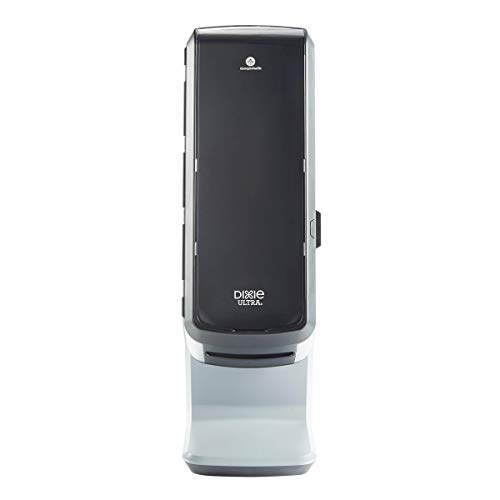

,asin,score,description,image_path
0,B000Y8UIVY,0.644342,Frigidaire Optional Washer.Dryer Pedestal - AP...,data/images/home_and_kitchen_10k/B000Y8UIVY.jpg
1,B08QGXPFS2,0.637398,We always attach great importance to our custo...,data/images/home_and_kitchen_10k/B08QGXPFS2.jpg
2,B01G2ENS38,0.620405,True HEPA filtration captures 99.97% of pollen...,data/images/home_and_kitchen_10k/B01G2ENS38.jpg
3,B0044R3LCY,0.618270,AW-120E Features: -Finish:Black -Cooling Syste...,data/images/home_and_kitchen_10k/B0044R3LCY.jpg
4,B095N5HLGQ,0.615474,The Sensibo Air & Sensor bundle allows you to ...,data/images/home_and_kitchen_10k/B095N5HLGQ.jpg
5,B00Y8WQ06Y,0.595558,A good drink tastes even better in your Stockh...,data/images/home_and_kitchen_10k/B00Y8WQ06Y.jpg
6,B00DPNVXU0,0.594878,Edsal high density stackable plastic storage b...,data/images/home_and_kitchen_10k/B00DPNVXU0.jpg
7,B001UFOGIQ,0.594752,Ex-Cell large capacity tabletop ashtray with s...,data/images/home_and_kitchen_10k/B001UFOGIQ.jpg
8,B00KAUL53Q,0.589233,Milk container made of glass for latte macchia...,data/images/home_and_kitchen_10k/B00KAUL53Q.jpg
9,B00AQ1JK7M,0.588733,"This pack of two 2"" High Profile Center Suppor...",data/images/home_and_kitchen_10k/B00AQ1JK7M.jpg


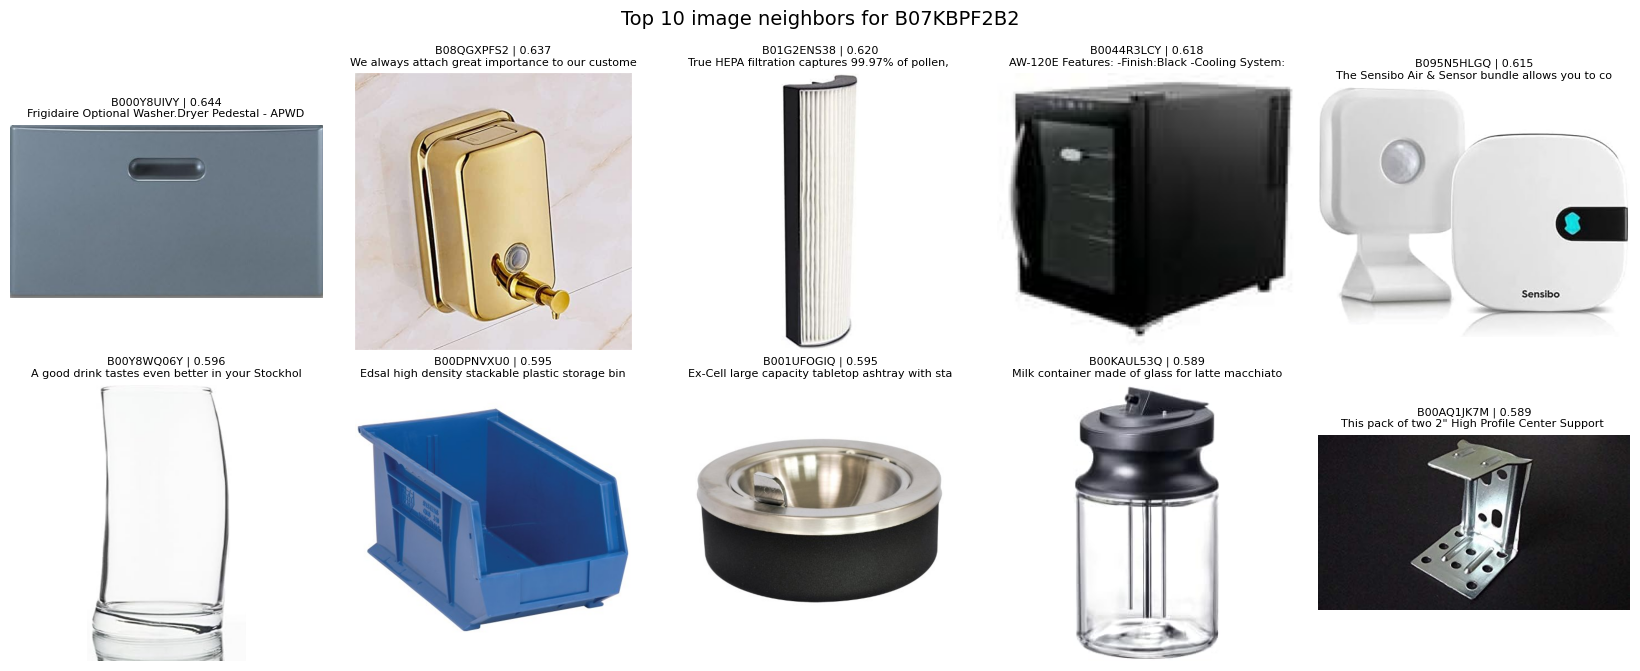

In [10]:
selected_asin = QUERY_ASIN or catalog_index.iloc[0]["asin"]
query_product, image_results = search_by_image(selected_asin)
print("Query product:", query_product["asin"], "—", query_product["description"][:180])
display(open_rgb(PROJECT_ROOT / query_product["image_path"]))
display(image_results)
show_product_grid(image_results, f"Top {TOP_K} image neighbors for {selected_asin}");

## 9. Scenario B — free text → top 10 matching product images

This is the cross-modal behavior SigLIP2 is especially useful for: the query uses the text tower and is compared directly with product image embeddings.

Text query: bed frame wooden


,asin,score,description,image_path
0,B081S1NXM8,0.107407,"From 2003 to 2020, MERITLINE have been providi...",data/images/home_and_kitchen_10k/B081S1NXM8.jpg
1,B01I2YFESI,0.102611,The Comfort bedding 11 Inch Eurotop Single Sid...,data/images/home_and_kitchen_10k/B01I2YFESI.jpg
2,B0749L2BHW,0.099310,Sophisticated elegance and neutral appeal are ...,data/images/home_and_kitchen_10k/B0749L2BHW.jpg
3,B000WFP6DY,0.083669,Comforter sets are designed to keep you update...,data/images/home_and_kitchen_10k/B000WFP6DY.jpg
4,B00AYABC7Q,0.081418,Laura Ashley Wakefield collection. The Comfort...,data/images/home_and_kitchen_10k/B00AYABC7Q.jpg
5,B0812VPJZK,0.078430,Description: This floating wall shelf is made ...,data/images/home_and_kitchen_10k/B0812VPJZK.jpg
6,B00MQGK7O0,0.078070,King duvet set includes One duvet 107 in. x 92...,data/images/home_and_kitchen_10k/B00MQGK7O0.jpg
7,B083KCK9V6,0.077879,AKK Hotel Quality Brushed Microfiber Sheet Set...,data/images/home_and_kitchen_10k/B083KCK9V6.jpg
8,B00A85YRII,0.076073,This amazing set will transfer your bedroom in...,data/images/home_and_kitchen_10k/B00A85YRII.jpg
9,B00869NVRQ,0.074323,"Reminiscent of simpler times, this coffee tabl...",data/images/home_and_kitchen_10k/B00869NVRQ.jpg


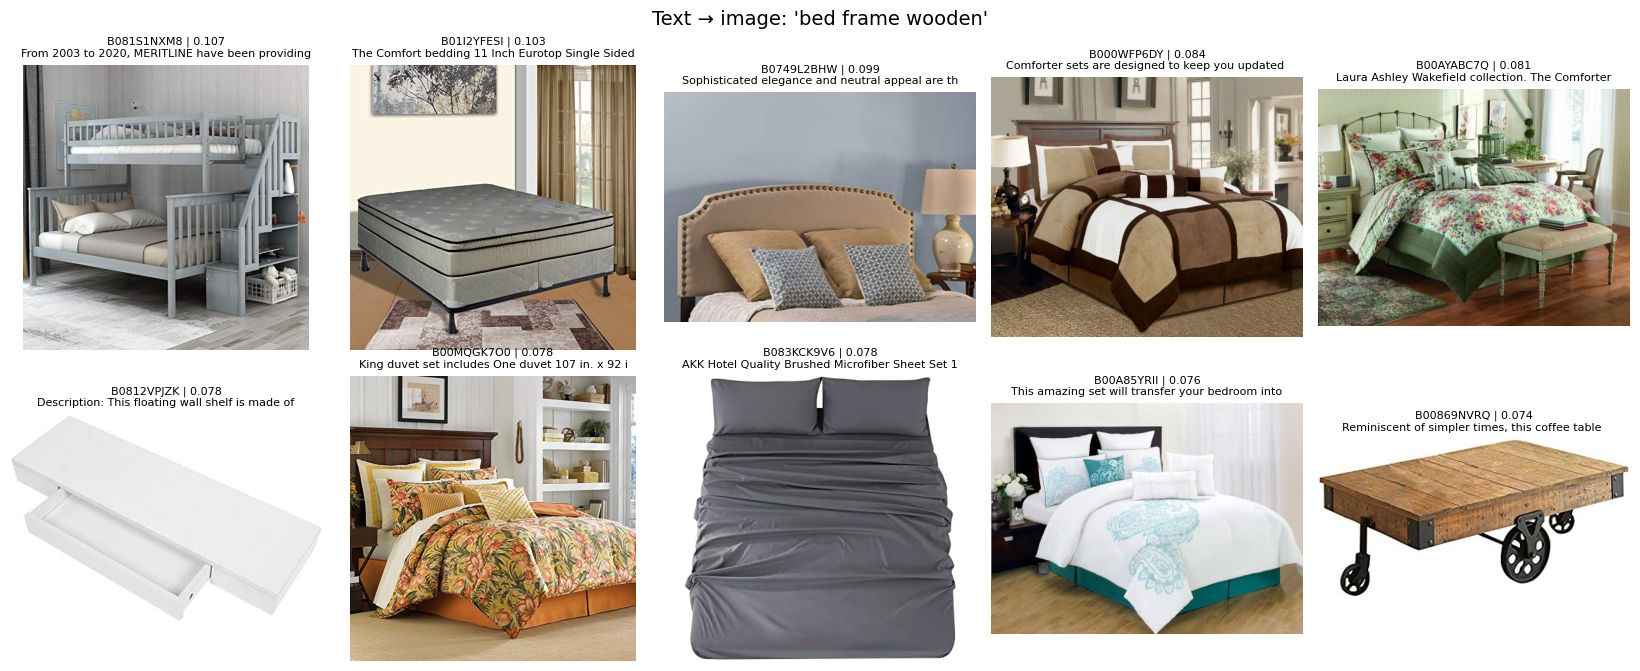

In [25]:
TEXT_QUERY = "bed frame wooden"
text_to_image_results = search_by_text(TEXT_QUERY, target="images")
print("Text query:", TEXT_QUERY)
display(text_to_image_results)
show_product_grid(text_to_image_results, f"Text → image: {TEXT_QUERY!r}");

## 10. Scenario C — free text → top 10 matching descriptions

This compares the query with stored description embeddings. It often behaves more like traditional semantic search than text-to-image search.

In [22]:
print(text_to_description_results[text_to_description_results['asin'] == 'B00869NVRQ']['description'][0][:100])
print(text_to_description_results[text_to_description_results['asin'] == 'B00869NVRQ']['description'][0][100:200])
print(text_to_description_results[text_to_description_results['asin'] == 'B00869NVRQ']['description'][0][200:300])
print(text_to_description_results[text_to_description_results['asin'] == 'B00869NVRQ']['description'][0][300:400])
print(text_to_description_results[text_to_description_results['asin'] == 'B00869NVRQ']['description'][0][400:500])

Reminiscent of simpler times, this coffee table exudes down-home country appeal. A distressed wood f
inish gives it a pleasingly rustic look. Four fully functional wheels, two small and two large, allo
w for versatile ease of movement. Its top is made from a thick, rectangular, wooden plank that's bot
h durable and sturdy. With old-world style and charm, this coffee table makes an appealing accent to
 a traditional country style home.


,asin,score,description,image_path
0,B01I2YFESI,0.809568,The Comfort bedding 11 Inch Eurotop Single Sid...,data/images/home_and_kitchen_10k/B01I2YFESI.jpg
1,B09HKNM8JS,0.802727,Color: Brown and white Color: Brown and white ...,data/images/home_and_kitchen_10k/B09HKNM8JS.jpg
2,B00RL145YS,0.795018,Soft for All seasons 300 Thread Count 100% bru...,data/images/home_and_kitchen_10k/B00RL145YS.jpg
3,B081W55CP8,0.793268,The Frozen 2 sheets include a fitted and flat ...,data/images/home_and_kitchen_10k/B081W55CP8.jpg
4,B01B2L4MX6,0.791979,Our decorative pillows have specific designed ...,data/images/home_and_kitchen_10k/B01B2L4MX6.jpg
5,B01KLLR61I,0.787328,"This high quality, 100% real wood decorative m...",data/images/home_and_kitchen_10k/B01KLLR61I.jpg
6,B09CG1G4V4,0.779339,Package Includes: Package include: Chaise Loun...,data/images/home_and_kitchen_10k/B09CG1G4V4.jpg
7,B0008F6DN0,0.778429,Optional Recirculating Charcoal Filter Kit Opt...,data/images/home_and_kitchen_10k/B0008F6DN0.jpg
8,B000WFP6DY,0.777858,Comforter sets are designed to keep you update...,data/images/home_and_kitchen_10k/B000WFP6DY.jpg
9,B08PVD4ZWD,0.776539,"Saemoza Multi-functional deformation sofa , La...",data/images/home_and_kitchen_10k/B08PVD4ZWD.jpg


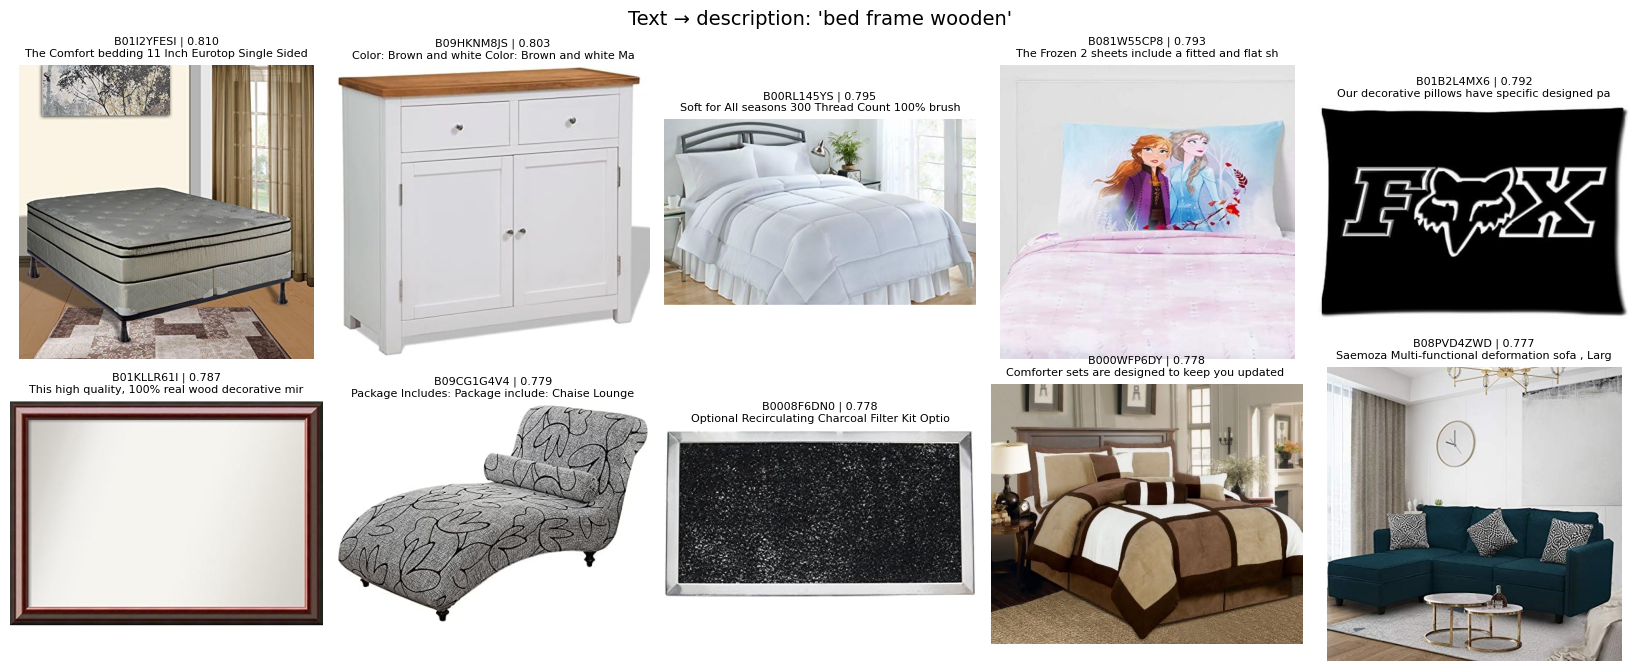

In [26]:
text_to_description_results = search_by_text(TEXT_QUERY, target="descriptions")
display(text_to_description_results)
show_product_grid(text_to_description_results, f"Text → description: {TEXT_QUERY!r}");

## 11. Save trained heads and reusable embeddings

The small head checkpoint is applied on top of the original Hugging Face checkpoint. The catalog CSV and both `.npy` matrices share row order.

In [13]:
if SAVE_PLAYGROUND_ARTIFACTS:
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    if RUN_TRAINING:
        trainable_state = {name: parameter.detach().cpu() for name, parameter in model.named_parameters() if name in trainable_names}
        torch.save(trainable_state, HEAD_CHECKPOINT)
    elif not LOAD_EXISTING_HEADS:
        print("No trained head checkpoint written because training and checkpoint loading were both disabled.")
    np.save(ARTIFACT_DIR / "image_embeddings.npy", image_embeddings.numpy())
    np.save(ARTIFACT_DIR / "description_embeddings.npy", description_embeddings.numpy())
    catalog_index[REQUIRED_COLUMNS].to_csv(ARTIFACT_DIR / "embedding_catalog.csv", index=False)
    with (ARTIFACT_DIR / "experiment.json").open("w") as file:
        json.dump({
            "model_id": MODEL_ID, "training_mode": TRAINING_MODE,
            "train_rows": len(train_df), "evaluation_rows": len(eval_df),
            "catalog_rows": len(catalog_index), "epochs": EPOCHS,
            "learning_rate": LEARNING_RATE, "training_history": training_history,
            "baseline_metrics": baseline_metrics, "trained_metrics": trained_metrics,
        }, file, indent=2)
    print("Saved:", sorted(path.name for path in ARTIFACT_DIR.iterdir()))
    print("Artifact directory:", ARTIFACT_DIR.resolve())
else:
    print("Artifact saving disabled.")

Saved: ['description_embeddings.npy', 'embedding_catalog.csv', 'experiment.json', 'image_embeddings.npy', 'trained_heads.pt']
Artifact directory: /Users/vachemacbook/Desktop/RecSystem/RecSystem/models/siglip2_playground


## How to play with this safely

- Change `TEXT_QUERY` and rerun the final search cells; no re-embedding is necessary.
- Set `QUERY_ASIN` to an ASIN shown in `catalog_index`, then rerun the image-search cell.
- Increase `CATALOG_ROWS` to 1,000 before increasing training size; a larger search space makes retrieval examples more informative.
- Compare before/after Recall@K, but do not over-interpret 64 training pairs or one epoch.
- For serious fine-tuning, use CUDA, larger in-batch negatives, a larger validation catalog, duplicate-aware splits, and multiple learning-rate/batch-size runs.
- Similarity retrieves substitutes or semantically related items. Complementary recommendations still need interaction/co-purchase data and a ranking objective.